In [1]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
    RestOf
)
from imagematerials.preprocessing import get_preprocessing_data
import numpy as np



In [2]:
#load historic data
from imagematerials.rest_of.resource_model import ResourceModel

steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                        image_mat_available = True, start_year = 1971,
                        scenario="SSP2_M_CP",
                        convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                        trade_data=True, path_input_data="../data/raw/rest-of", 
                        path_input_data_image = Path("../data/raw/image"))

aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                        image_mat_available = True, start_year = 1998, 
                        scenario="SSP2_M_CP", end_year = 2024, path_input_data="../data/raw/rest-of", 
                        path_input_data_image = Path("../data/raw/image")
                        )


In [3]:
from imagematerials.rest_of import rest_of_preprocessing

In [4]:
image_scenario = "SSP2_M_CP"
climate_policy_scenario_dir = Path("..", "data", "raw", "image", image_scenario)

In [5]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1920
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1970, 2100, 1)


bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None) 
vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None)
rest_sector = rest_of_preprocessing(Path("..", "data", "raw"), 
                    image_scenario_directory = climate_policy_scenario_dir)

# TODO fix this for real in the future
prep_data = vhc_sector.prep_data

target_materials = [
"Aluminium", "Brick", "Cement", "Concrete", 
"Copper", "Glass", "Steel", "Wood"
]

vhc_sector = Sector('vehicles', prep_data)
rest_sector = Sector(name='rest_of', 
                    data = rest_sector,)

factory = ModelFactory(
[bld_sector, vhc_sector, rest_sector], complete_timeline
).add(GenericStocks, ["buildings", "vehicles"]
).add(GenericMaterials,  "vehicles"
).add(MaterialIntensities, "buildings",
).add(RestOf, "rest_of", input_sources={
    "gompertz_coefs": "rest_of",
    "gdp_per_capita": "rest_of",
    "population": "rest_of",
}
)
model = factory.finish()

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    model.simulate(simulation_timeline)



c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1566: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


In [6]:
from imagematerials.rest_of.const import IAI_TO_IMAGE_CLASSES


In [7]:
IAI_TO_IMAGE_CLASSES.get('Western & Central Europe')

['class_ 11', 'class_ 12', 'class_ 13']

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


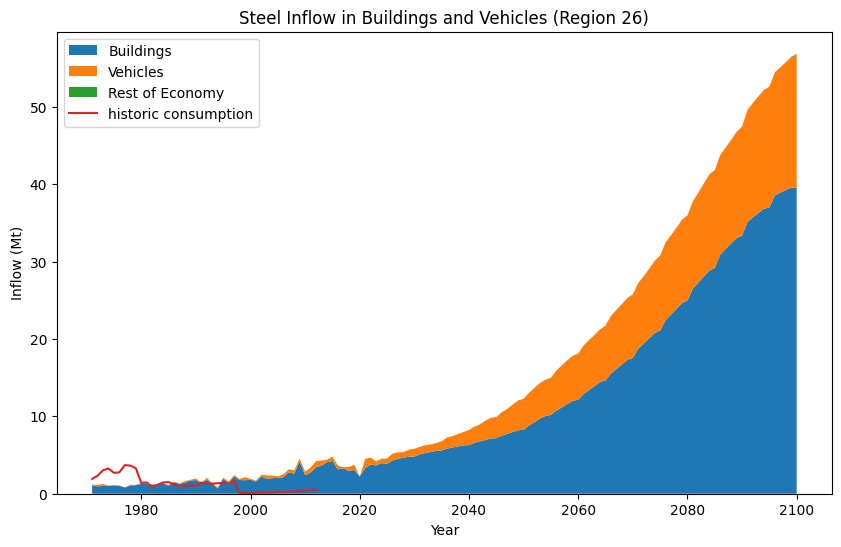

In [17]:
# stack plot of material inflow in buildings and vehicles
material_sel = "Steel"
all_regions = list(range(1, 27))
region_sel = "26"
import matplotlib.pyplot as plt

inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel, Region = region_sel).pint.to("Mt").sum(["Type"]).loc[1971:]
inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = material_sel, Region = region_sel).pint.to("Mt").sum(["Type"]).loc[1971:]
inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel, Region = region_sel).pint.to("Mt").loc[1971:].rename({'Time': 'time'})
years = inflow_buildings.coords['time'].values

historic_consumption_data = steel.historic_consumption_data.loc[:, f"class_ {region_sel}"] / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(years, inflow_buildings, inflow_vehicles, inflow_rest, labels=['Buildings', 'Vehicles', 'Rest of Economy'])
historic_consumption_data.plot(label = "historic consumption")


ax.set_title(f'{material_sel} Inflow in Buildings and Vehicles (Region {region_sel})')
ax.set_xlabel('Year')
ax.set_ylabel('Inflow (Mt)')
ax.legend(loc='upper left')
plt.show()


c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


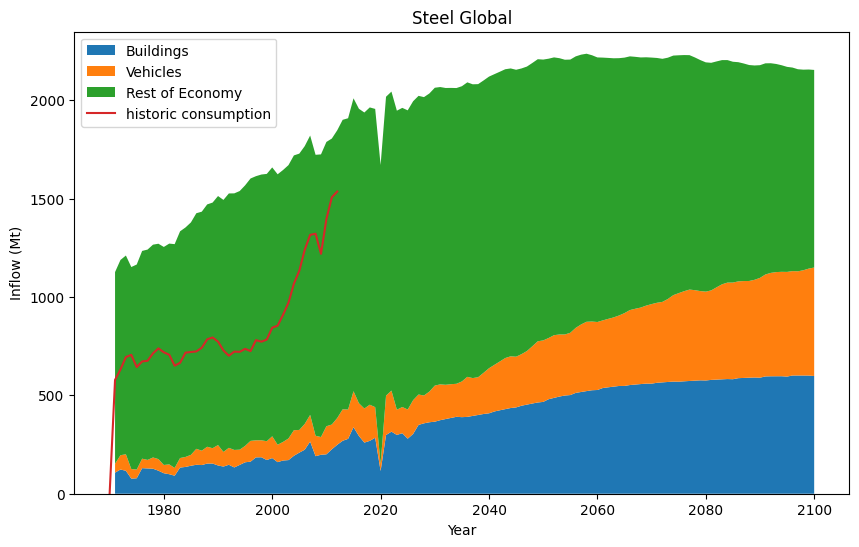

In [9]:
# stack plot of material inflow in buildings and vehicles
material_sel = "Steel"
all_regions = list(range(1, 27))

import matplotlib.pyplot as plt

inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = material_sel).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel).pint.to("Mt").loc[1971:].sum(["Region"]).rename({'Time': 'time'})
years = inflow_buildings.coords['time'].values

historic_consumption_data = steel.historic_consumption_data.sum(axis = 1) / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(years, inflow_buildings, inflow_vehicles, inflow_rest, labels=['Buildings', 'Vehicles', 'Rest of Economy'])
historic_consumption_data.plot(label = "historic consumption")


ax.set_title(f'{material_sel} Global')
ax.set_xlabel('Year')
ax.set_ylabel('Inflow (Mt)')
ax.legend(loc='upper left')
plt.show()

In [10]:
aluminium.historic_consumption_data

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe,Japan
1988,NaN,687000.0,NaN,NaN,NaN,NaN,381000.0,NaN,NaN,4728000.0,2589000.0
1989,NaN,988000.0,NaN,NaN,1.333230e+03,6.787897e+06,381000.0,1.075250e+05,2.163078e+06,4840000.0,2742000.0
1990,6.018660e+05,1009000.0,NaN,NaN,1.729161e+03,6.891520e+06,328000.0,1.259970e+05,2.374377e+06,5071000.0,2683000.0
1991,6.118305e+05,1074000.0,7.865230e+02,NaN,2.519060e+05,7.438025e+06,266000.0,6.397000e+04,2.705961e+06,5236000.0,2908000.0
1992,6.086064e+05,1101000.0,NaN,4.689961e+06,2.524190e+05,7.105333e+06,307000.0,7.864901e+04,2.716907e+06,5346000.0,2671000.0
1993,6.076788e+05,1230000.0,NaN,4.738436e+06,2.760718e+05,6.243607e+06,410000.0,NaN,2.793502e+06,5376000.0,2467000.0
1994,5.732989e+05,1419000.0,NaN,3.989005e+06,NaN,5.176989e+06,416000.0,2.668526e+05,3.246617e+06,5364000.0,2718000.0
1995,6.906843e+05,1555000.0,NaN,2.362097e+06,6.387243e+04,5.748263e+06,379000.0,4.773458e+04,3.214576e+06,5648000.0,2832000.0
1996,1.148404e+06,1734000.0,NaN,2.216125e+06,4.868501e+04,6.105438e+06,188000.0,6.058961e+06,3.368716e+06,5601000.0,2975000.0
1997,1.258448e+06,1819000.0,NaN,1.749081e+06,3.714252e+03,5.918598e+06,424000.0,6.575495e+06,3.252512e+06,5788000.0,3017000.0


In [11]:
inflow_buildings

Magnitude,[107.19152660108921 123.18900859496385 116.61653808504134 76.79570282537588 78.55591821594558 129.97008765616485 128.60950670645408 127.23357574946115 117.11867170722606 104.15023500536348 99.22958787646144 91.51938085181251 132.94360013201532 136.233144199952 142.202267498153 147.20363242981875 145.76112653960143 153.27549130921236 153.50455843817514 143.6726414333566 138.0787635405571 147.25560345152206 133.63122966562068 146.49454245468513 159.85137043189812 163.112279737753 184.77397901832077 185.47652919968215 171.27390538825674 181.31423872147747 160.6273452587413 168.8502158632821 171.0001490026661 192.8405544309471 208.91804631970496 223.89880353824202 265.35216463847485 190.86984217455114 198.14934283564463 200.35123098528857 225.9784998065 248.86030720828586 269.2030625768972 279.03690563625474 338.24436470782575 293.4949259399444 259.8991338179712 268.79022007756305 284.7086785392719 115.58864601669109 298.3057492642151 315.6197774196861 298.85792290567235 307.70840420308804 279.8309243143913 304.000245320711 350.0206994295048 357.904452035233 363.3862918952865 366.32486815292316 373.9735796029539 379.75147637780424 385.47096665516835 391.01783269481894 389.32704011489557 390.69365585689417 395.6329781211688 400.42772893663243 405.4268375065245 408.8064952777565 418.30592646332923 424.2922431773543 430.0877634313574 435.7691954178132 438.8585699012908 447.4674047988659 453.12045241698723 458.65588263180075 463.95625230344825 466.88110434188195 480.5181292696526 487.3415656097873 494.06043659299894 499.35277714524614 501.671839763776 512.6674601740687 517.3386155407436 521.8356301465991 526.1503882918655 527.4258970353942 537.4723769125974 541.1078055107664 544.5653557261229 547.867098801385 548.1615525264212 552.6333766120702 555.1428707638325 557.548360480719 559.8477579052965 559.6576405285264 564.1229290697894 566.2223330706527 568.2225298957227 570.14278087404 569.630106584526 571.5989168601915 573.2834768091175 574.91856505447 576.499800777712 575.804215348376 578.7855217735425 580.2693111910346 581.6833732129993 583.0623706422169 582.2081105533099 587.576061293565 588.7612733199189 589.9054444462781 590.998775857975 589.9413802683665 596.4690790860934 597.1133385029266 597.2762307259053 597.3636853509635 595.5906496790695 601.09127561718 601.0979376056616 601.0315658294921 600.8444828809919 598.5638732644915]
Units,megametric_ton


In [12]:
# # plot steel inflow
steel_rest = model.rest_of.get('inflow_materials_rest').sel(material = 'Steel').pint.to("Mt").sum("Region").loc[1980:]
steel_buildings = model.buildings.get('inflow_materials').to_array().sel(material = 'Steel').pint.to("Mt").sum(["Region", "Type"]).loc[1980:]
steel_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = 'Steel').pint.to("Mt").sum(["Region", "Type"]).loc[1980:]
steel_mt.loc[1980:].plot()

both = (steel_buildings + steel_vehicles)
both.plot()
steel_rest = steel_rest.rename({'Time': 'time'})
both = (both + steel_rest)
both.plot()

steel_rest.plot()   

NameError: name 'steel_mt' is not defined

In [ ]:
# sum inflow materials for steel, sum also per types keep regions and year

materials_dict_metal = {
    'Steel' : 'Steel',
    'Aluminium' : 'Aluminium',
    'Copper' : 'Cu',
}

materials_dict_nmm = {
    'Cement' : 'Cement',
    'Sand' : 'Sand'
}

# Conversion factors
# always taking the lower range numbers to be cautios

# https://civiltoday.com/civil-engineering-materials/cement/10-cement-ingredients-with-functions
# Cement: Lime 60-75%, Silica 17-25%, other aggregates
# https://concretesupplyco.com/concrete-basics/
# Concrete:  10% cement, 20% air and water, 30% sand, and 40% gravel --> 30% + 40% = 70%
# https://samsa.org.uk/key_uses/glass.php, https://www.carmeuse.com/na-en/references/case-studies-success-stories/limestone-glassmaking-what-you-need-know
# Sand (silica) in glass: 70%, lime: 15%

cement_in_concrete = 0.1
sand_in_cement_conversion = 0.17 #(silica)
sand_gravel_in_concrete_conversion = 0.7
sand_in_glass_conversion = 0.7

only_buildings = ['Cement', 'Concrete']
only_vehicles = ['Glass']
not_in_any = ['Sand']

def sum_inflows_for_output(materials_dict, resource_group):
    for key, value in materials_dict.items():
        print(key)
        if key not in only_buildings and key not in only_vehicles and not key in not_in_any:
            inflow_buildings = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material=key).loc[1961:]
            inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sum(['Type']).sel(material=value).loc[1961:]
            total_material = inflow_buildings + inflow_vehicles
        if key == 'Cement':
            # add concrete to cement
            inflow_buildings_cement = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material=key).loc[1961:]
            inflow_buildings_concrete = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Concrete').loc[1961:] * cement_in_concrete
            total_material = inflow_buildings_cement + inflow_buildings_concrete
        if key == 'Sand':
            inflow_buildings_cement_sand = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Cement').loc[1961:]*sand_in_cement_conversion
            inflow_buildings_concrete_sand_via_cement = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Concrete').loc[1961:] * cement_in_concrete * sand_in_cement_conversion
            inflow_buildings_sand_in_concrete = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Concrete').loc[1961:] * sand_gravel_in_concrete_conversion
            inflow_vehicles_sand = model.vehicles.get('inflow_materials').to_array().sum(['Type']).sel(material='Glass').loc[1961:] * sand_in_glass_conversion
            total_material = inflow_buildings_cement_sand + inflow_buildings_concrete_sand_via_cement + inflow_buildings_sand_in_concrete + inflow_vehicles_sand

        # from total_material create a csv that has the years as rows and regions as columns, mae sure that region names are no just '1' but 'class_ 1'
        # also drop material dimension
        if key not in ['Copper', 'Cement', 'Sand']:
            total_material = total_material.drop_vars('material')
        # change the region coordinate so that it is class_ 1 instead of 1 , ...
        # Get the current region values
        regions = total_material.coords['Region'].values

        # Create new region names
        new_regions = [f'class_ {r}' for r in regions]

        # Assign the new region names to the coordinate
        total_material = total_material.assign_coords(Region=new_regions)
        # to t
        total_material = total_material.pint.to('t')
        # save as pandas to save as csv
        total_material = total_material.rename("total_material")
        # write key with a small letter
        key = key.lower()
        # to pandas
        total_material = total_material.to_dataframe().unstack()
        # drop unessecary column level index
        total_material.columns = total_material.columns.droplevel(0)
        # save as csv
        if key == 'sand':
            key = 'sand_gravel_crushed_rock'
            total_material = total_material.loc[1971:]
        else: 
            pass
        total_material.to_csv(f'../data/raw/rest-of/{resource_group}/image_materials_{key}.csv')
        print('done', key)
    return total_material


total_material_metals = sum_inflows_for_output(materials_dict_metal, 'metals')
total_material_nmm = sum_inflows_for_output(materials_dict_nmm, 'nmm')



Steel
done steel
Aluminium
done aluminium
Copper
done copper
Cement
done cement
Sand


c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


done sand_gravel_crushed_rock


c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
